<a href="https://colab.research.google.com/github/HMBinara/ML_Project/blob/main/Final_Master_Finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
#import Libries
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [69]:
#Load the Data Set
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Master_Finance_Data.csv')


Saving Master_Finance_Data.csv to Master_Finance_Data (2).csv


In [70]:
#show Row and column
df.shape


(50000, 16)

In [71]:
#Get the Some Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   50000 non-null  int64  
 1   occupation_status     50000 non-null  object 
 2   years_employed        50000 non-null  float64
 3   annual_income         50000 non-null  int64  
 4   credit_score          50000 non-null  int64  
 5   savings_assets        50000 non-null  int64  
 6   current_debt          50000 non-null  int64  
 7   defaults_on_file      50000 non-null  int64  
 8   debt_to_income_ratio  50000 non-null  float64
 9   Investment_Avenues    18943 non-null  object 
 10  Mutual_Funds          18943 non-null  float64
 11  Equity_Market         18943 non-null  float64
 12  Fixed_Deposits        18943 non-null  float64
 13  Stock_Marktet         18943 non-null  object 
 14  Duration              18943 non-null  object 
 15  stability_score    

In [72]:
#Display Frist Five Column
df.head()

,age,occupation_status,years_employed,annual_income,credit_score,savings_assets,current_debt,defaults_on_file,debt_to_income_ratio,Investment_Avenues,Mutual_Funds,Equity_Market,Fixed_Deposits,Stock_Marktet,Duration,stability_score
0,40,Employed,17.2,25579,692,895,10820,0,0.423,NaN,NaN,NaN,NaN,NaN,NaN,7.207219
1,33,Employed,7.3,43087,627,169,16550,0,0.384,NaN,NaN,NaN,NaN,NaN,NaN,10.510126
2,42,Student,1.1,20840,689,17,7852,0,0.377,NaN,NaN,NaN,NaN,NaN,NaN,6.367061
3,53,Student,0.5,29147,692,1480,11603,0,0.398,NaN,NaN,NaN,NaN,NaN,NaN,8.069545
4,32,Employed,12.5,63657,630,209,12424,0,0.195,Yes,3.0,4.0,1.0,Yes,3-5 years,16.370064


In [73]:
# 1. Handling Missing Values in Numerical Columns
# Since 'Mutual_Funds', 'Equity_Market', and 'Fixed_Deposits' are based on rankings (1-7),
# we impute missing values using the 'Median' to maintain the central tendency without being affected by outliers.
numerical_cols = ['Mutual_Funds', 'Equity_Market', 'Fixed_Deposits']
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# 2. Handling Missing Values in Categorical Columns
# For categorical fields like 'Investment_Avenues', 'Stock_Marktet', and 'Duration',
# we fill missing entries with the 'Mode' (the most frequent value) to preserve the original distribution.
categorical_cols = ['Investment_Avenues', 'Stock_Marktet', 'Duration']
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [74]:
df.head()

,age,occupation_status,years_employed,annual_income,credit_score,savings_assets,current_debt,defaults_on_file,debt_to_income_ratio,Investment_Avenues,Mutual_Funds,Equity_Market,Fixed_Deposits,Stock_Marktet,Duration,stability_score
0,40,Employed,17.2,25579,692,895,10820,0,0.423,Yes,2.6,3.5,3.333333,Yes,1-3 years,7.207219
1,33,Employed,7.3,43087,627,169,16550,0,0.384,Yes,2.6,3.5,3.333333,Yes,1-3 years,10.510126
2,42,Student,1.1,20840,689,17,7852,0,0.377,Yes,2.6,3.5,3.333333,Yes,1-3 years,6.367061
3,53,Student,0.5,29147,692,1480,11603,0,0.398,Yes,2.6,3.5,3.333333,Yes,1-3 years,8.069545
4,32,Employed,12.5,63657,630,209,12424,0,0.195,Yes,3.0,4.0,1.000000,Yes,3-5 years,16.370064


In [75]:
# 2. Identify Categorical Columns
# List of columns with 'object' data type that need conversion to numerical
categorical_features = ['occupation_status', 'Investment_Avenues', 'Stock_Marktet', 'Duration']

# 3. Apply One-Hot Encoding
# We transform text categories into separate binary (0 or 1) columns.
# 'drop_first=True' helps avoid redundancy by removing the first category of each feature.
df = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# 4. Verification Step
# Check if the object types are gone and replaced by uint8 or int
print("--- New Dataset Information ---")
print(df.info())

--- New Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              50000 non-null  int64  
 1   years_employed                   50000 non-null  float64
 2   annual_income                    50000 non-null  int64  
 3   credit_score                     50000 non-null  int64  
 4   savings_assets                   50000 non-null  int64  
 5   current_debt                     50000 non-null  int64  
 6   defaults_on_file                 50000 non-null  int64  
 7   debt_to_income_ratio             50000 non-null  float64
 8   Mutual_Funds                     50000 non-null  float64
 9   Equity_Market                    50000 non-null  float64
 10  Fixed_Deposits                   50000 non-null  float64
 11  stability_score                  50000 non-null 

In [76]:
df.head()


,age,years_employed,annual_income,credit_score,savings_assets,current_debt,defaults_on_file,debt_to_income_ratio,Mutual_Funds,Equity_Market,Fixed_Deposits,stability_score,occupation_status_Self-Employed,occupation_status_Student,Investment_Avenues_Yes,Stock_Marktet_Yes,Duration_3-5 years,Duration_Less than 1 year,Duration_More than 5 years
0,40,17.2,25579,692,895,10820,0,0.423,2.6,3.5,3.333333,7.207219,False,False,True,True,False,False,False
1,33,7.3,43087,627,169,16550,0,0.384,2.6,3.5,3.333333,10.510126,False,False,True,True,False,False,False
2,42,1.1,20840,689,17,7852,0,0.377,2.6,3.5,3.333333,6.367061,False,True,True,True,False,False,False
3,53,0.5,29147,692,1480,11603,0,0.398,2.6,3.5,3.333333,8.069545,False,True,True,True,False,False,False
4,32,12.5,63657,630,209,12424,0,0.195,3.0,4.0,1.000000,16.370064,False,False,True,True,True,False,False


In [77]:
# 1. Check for Duplicate Rows
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

# 2. Check for Constant Columns (Columns with only 1 unique value)
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(f"Constant Columns to drop: {constant_cols}")

Total Duplicate Rows: 0
Constant Columns to drop: []


In [78]:
# 3. Handling Outliers (Simple check for Age and Income)
# Removing rows where age > 100 or annual_income < 0
outliers_condition = (df['age'] > 100) | (df['annual_income'] < 0)
outliers_count = df[outliers_condition].shape[0]
print(f"Outlier Rows found: {outliers_count}")

Outlier Rows found: 0


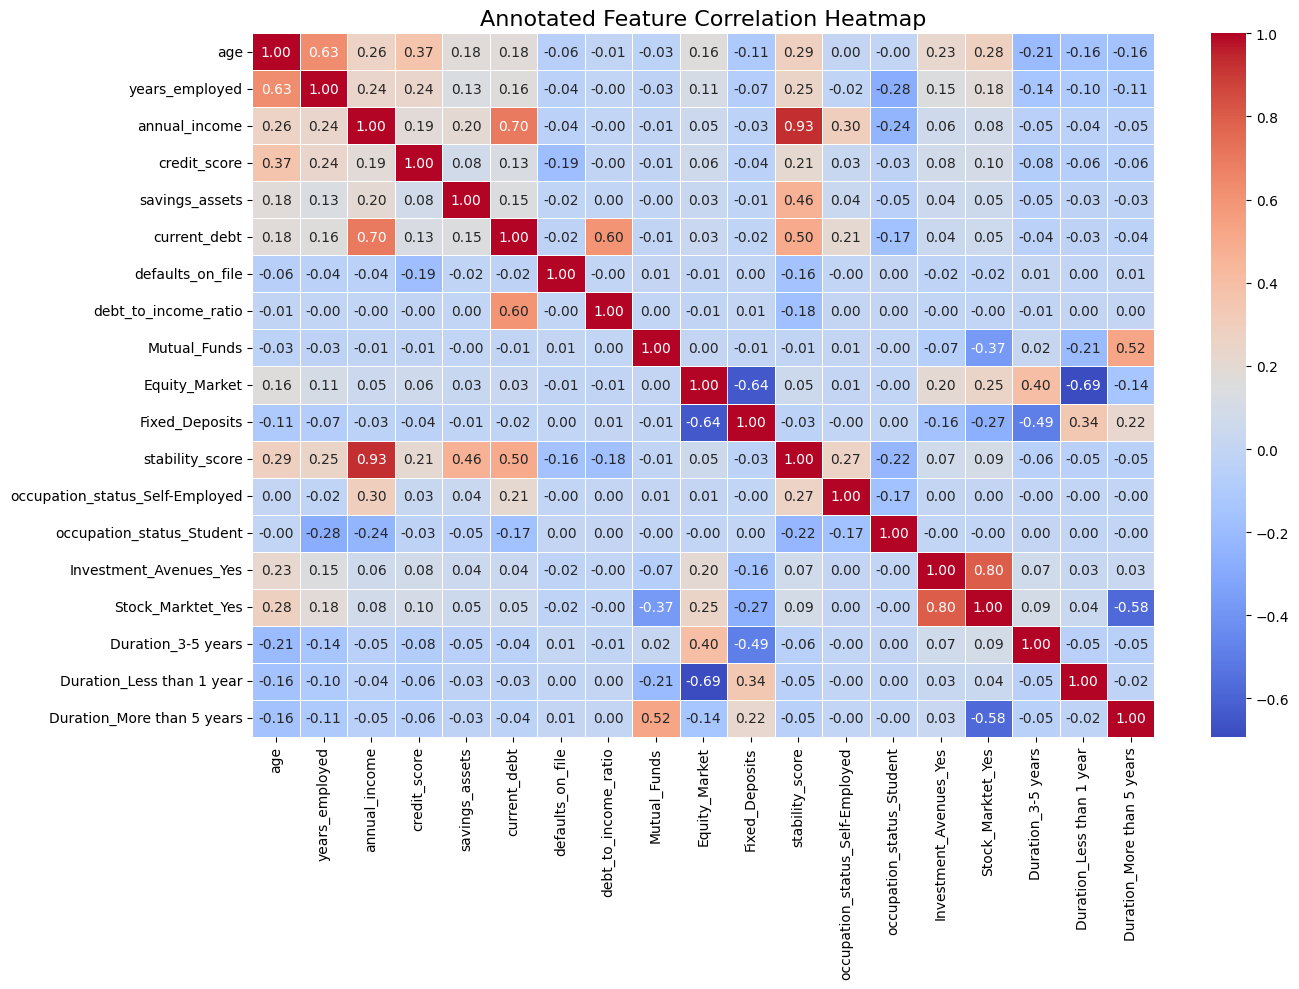

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Setup Figure Size
# Increasing dimensions slightly to ensure the annotations are clearly visible
plt.figure(figsize=(14,10))

# 2. Generate Correlation Matrix
# Computing the Pearson correlation coefficient between all numeric features
correlation_matrix = df.corr()

# 3. Create Annotated Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

# 4. Adding Title and Layout Adjustments
plt.title('Annotated Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()

#5. Display the plot
plt.show()

In [81]:
#Drop the Weak Feathurs
df = df.drop(['age', 'defaults_on_file', 'debt_to_income_ratio', 'Mutual_Funds', 'occupation_status_Student', 'Duration_3-5 years', 'Duration_Less than 1 year', 'Duration_More than 5 years'], axis=1)



In [82]:
df.shape

(50000, 11)

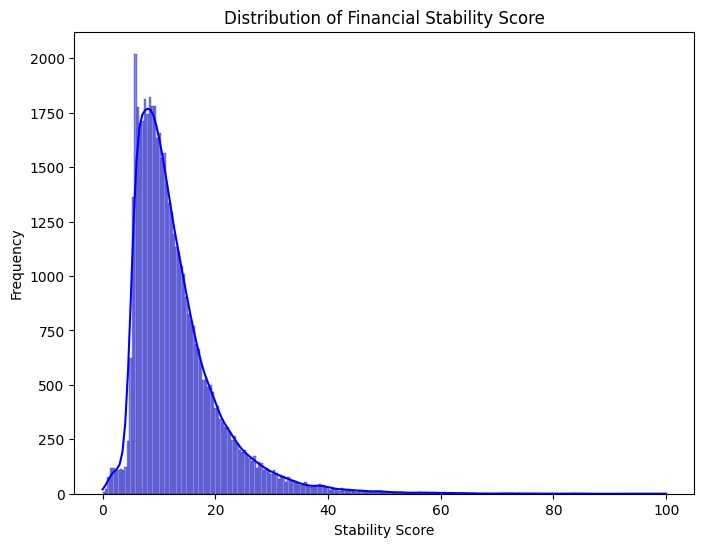

In [83]:
# Distribution of Target Variable (Stability Score)
plt.figure(figsize=(8, 6))
sns.histplot(df['stability_score'], kde=True, color='blue')
plt.title('Distribution of Financial Stability Score')
plt.xlabel('Stability Score')
plt.ylabel('Frequency')
plt.show()

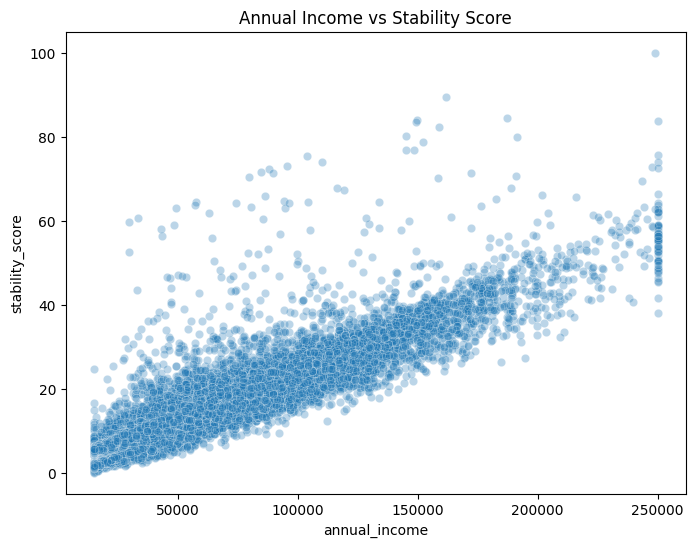

In [84]:
# Relationship between Income and Stability Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='annual_income', y='stability_score', data=df, alpha=0.3)
plt.title('Annual Income vs Stability Score')
plt.show()

In [87]:
#Traing the Model

# 1. Features (X) and Target (y)
X = df.drop(columns=['stability_score'])
y = df['stability_score']

# 2. Split data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and Train the Model
# n_estimators=100 means we use 100 decision trees
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)





RandomForestRegressor(random_state=42)

In [88]:
# Evaluate the Model
predictions = model.predict(X_test)
print(f"Model Accuracy (R2 Score): {r2_score(y_test, predictions):.4f}")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, predictions):.4f}")

Model Accuracy (R2 Score): 0.9834
Mean Absolute Error: 0.4818


In [89]:
# 6. Save the Model as a Pickle file
with open('finance_model.pkl', 'wb') as f:
    pickle.dump(model, f)

# 7. Save Feature Columns (Very important for Flask API)
model_columns = list(X.columns)
with open('finance_columns.pkl', 'wb') as f:
    pickle.dump(model_columns, f)

print("\nModel Trained and Files Saved Successfully!")


Model Trained and Files Saved Successfully!
